In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('../data/KV-traces-2026.zst', compression='zstd')
# To save as a standard CSV:
df.to_csv('../data/kv-traces-2026.csv', index=False)

KeyboardInterrupt: 

In [3]:
file_path = '../data/kv-traces-2026.csv'
df = pd.read_csv("../data/kv-traces-2026.csv", nrows=200000)


In [4]:
print("First 10 rows:")
print(df.head(10))

print("\nColumn names:")
print(df.columns)

print("\nDataset shape (rows, columns):")
print(df.shape)
print("\nData types of each column:")
print(df.dtypes)

First 10 rows:
          key   op  size  op_count  key_size
0  1668757755  SET    82         1        40
1  1668757755  GET     0         1        40
2  1668757805  SET   208         1        63
3  1668757805  GET     0         1        63
4  1665498006  GET   104         2        64
5  1666258101  GET    81         2        23
6  1665497896  GET   169        18        78
7  1665702915  SET   109         1        40
8  1665702915  GET     0         1        40
9  1665497896  GET   169        18        78

Column names:
Index(['key', 'op', 'size', 'op_count', 'key_size'], dtype='str')

Dataset shape (rows, columns):
(200000, 5)

Data types of each column:
key         int64
op            str
size        int64
op_count    int64
key_size    int64
dtype: object


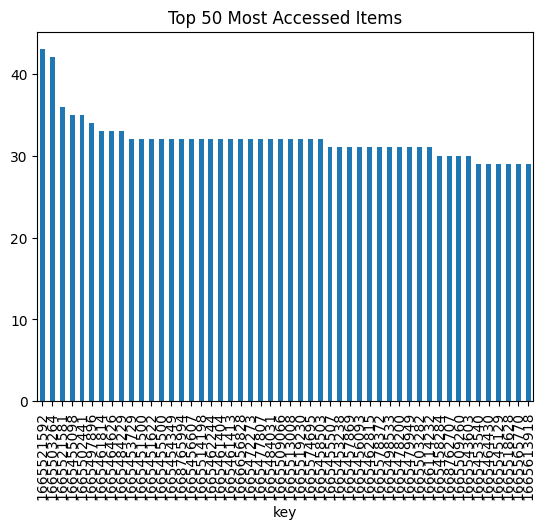

In [5]:
import matplotlib.pyplot as plt
key_col = df.columns[0] 
df[key_col].value_counts().head(50).plot(kind='bar')
plt.title("Top 50 Most Accessed Items")
plt.show()

Sampling dataset

In [6]:
df = pd.read_csv(file_path, nrows=100000)

print(df.head())
print(df.shape)

          key   op  size  op_count  key_size
0  1668757755  SET    82         1        40
1  1668757755  GET     0         1        40
2  1668757805  SET   208         1        63
3  1668757805  GET     0         1        63
4  1665498006  GET   104         2        64
(100000, 5)


Encoding and labelling

In [ ]:
# df['op'] = df['op'].map({'GET': 0, 'SET': 1})
# last_seen = {}
# recency = []

# for i, key in enumerate(df['key']):
#     if key in last_seen:
#         recency.append(i - last_seen[key])
#     else:
#         # recency.append(-1)
#         recency.append(0)
#     last_seen[key] = i

# df['recency'] = recency
# #frequency computation
# freq = {}
# frequency = []

# for key in df['key']:
#     freq[key] = freq.get(key, 0) + 1
#     frequency.append(freq[key])

# df['frequency'] = frequency

#  # creating label
# # K = 200  # lookahead window

# # labels = []

# # keys = df['key'].tolist()

# # for i in range(len(keys)):
# #     future_window = keys[i+1:i+K+1]
# #     if keys[i] in future_window:
# #         labels.append(1)
# #     else:
# #         labels.append(0)

# # df['label'] = labels


In [ ]:
# from collections import deque

# window = deque(maxlen=50)
# recent_freq = []

# for key in df['key']:
#     recent_freq.append(list(window).count(key))
#     window.append(key)

# df['recent_freq'] = recent_freq

In [ ]:
# # K = 20
# # labels = []
# # keys = df['key'].tolist()
# # for i in range(len(keys)):
# #     future_window = keys[i+1:i+K+1]
# #     if keys[i] in future_window[:5]:
# #         labels.append(1)
# #     else:
# #         labels.append(0)
# # df['label'] = labels

# K = 50
# labels = []
# keys = df['key'].tolist()

# for i in range(len(keys)):
#     future_window = keys[i+1:i+K+1]

#     if keys[i] in future_window:
#         labels.append(1)
#     else:
#         labels.append(0)

# df['label'] = labels

In [12]:
import pandas as pd
from collections import deque

# ======================
# LOAD RAW DATA
# ======================

df = pd.read_csv(
    "../data/kv-traces-2026.csv",
    nrows=200000
)

print("Loaded dataset")

# ======================
# ENCODE OPERATION
# ======================

df['op'] = df['op'].map({
    'GET': 0,
    'SET': 1
})

print("Encoded operations")

# ======================
# RECENCY FEATURE
# ======================

last_seen = {}
recency = []

for i, key in enumerate(df['key']):

    if key in last_seen:
        recency.append(i - last_seen[key])
    else:
        recency.append(-1)

    last_seen[key] = i

df['recency'] = recency

print("Created recency feature")

# ======================
# FREQUENCY FEATURE
# ======================

freq = {}
frequency = []

for key in df['key']:

    freq[key] = freq.get(key, 0) + 1

    frequency.append(freq[key])

df['frequency'] = frequency

print("Created frequency feature")

# ======================
# RECENT FREQUENCY
# ======================

window = deque(maxlen=50)

recent_freq = []

for key in df['key']:

    recent_freq.append(
        list(window).count(key)
    )

    window.append(key)

df['recent_freq'] = recent_freq

print("Created recent frequency feature")

# ======================
# CREATE LABELS
# ======================

K = 50

labels = []

keys = df['key'].tolist()

for i in range(len(keys)):

    future_window = keys[i+1:i+K+1]

    if keys[i] in future_window:
        labels.append(1)
    else:
        labels.append(0)

df['label'] = labels

print("Created labels")

# ======================
# SAVE PROCESSED DATA
# ======================

df.to_csv(
    "../data/processed.csv",
    index=False
)

print("\nSaved processed dataset")
print(df.head())
print(df.columns)

Loaded dataset
Encoded operations
Created recency feature
Created frequency feature
Created recent frequency feature
Created labels

Saved processed dataset
          key   op  size  op_count  key_size  recency  frequency  recent_freq  \
0  1668757755  1.0    82         1        40       -1          1            0   
1  1668757755  0.0     0         1        40        1          2            1   
2  1668757805  1.0   208         1        63       -1          1            0   
3  1668757805  0.0     0         1        63        1          2            1   
4  1665498006  0.0   104         2        64       -1          1            0   

   label  
0      1  
1      0  
2      1  
3      0  
4      1  
Index(['key', 'op', 'size', 'op_count', 'key_size', 'recency', 'frequency',
       'recent_freq', 'label'],
      dtype='str')


In [ ]:
# 

In [7]:
window = 50
recent_counts = []

keys = df['key'].tolist()

for i in range(len(keys)):
    start = max(0, i - window)
    count = 0
    
    for j in range(start, i):
        if keys[j] == keys[i]:
            count += 1
            
    recent_counts.append(count)

df['recent_freq'] = recent_counts

In [8]:
print(df.head())
print(df['label'].value_counts())

          key   op  size  op_count  key_size  recency  frequency  label  \
0  1668757755  1.0    82         1        40        0          1      1   
1  1668757755  0.0     0         1        40        1          2      0   
2  1668757805  1.0   208         1        63        0          1      1   
3  1668757805  0.0     0         1        63        1          2      0   
4  1665498006  0.0   104         2        64        0          1      0   

   recent_freq  
0            0  
1            1  
2            0  
3            1  
4            0  
label
0    76629
1    23371
Name: count, dtype: int64


In [9]:
df.fillna(0, inplace=True)

,key,op,size,op_count,key_size,recency,frequency,label,recent_freq
0,1668757755,1.0,82,1,40,0,1,1,0
1,1668757755,0.0,0,1,40,1,2,0,1
2,1668757805,1.0,208,1,63,0,1,1,0
3,1668757805,0.0,0,1,63,1,2,0,1
4,1665498006,0.0,104,2,64,0,1,0,0
...,...,...,...,...,...,...,...,...,...
99995,1666047513,0.0,109,1,68,2,2,0,1
99996,1665483245,0.0,140,1,62,6887,7,0,0
99997,1668788398,0.0,104,1,64,1756,3,0,0
99998,1668788419,0.0,157,2,63,0,1,0,0


BASELINE ML MODEL FOR COMPARISON

In [10]:
# feature selection
# features = ['recency', 'frequency', 'op', 'size', 'key_size']
# features = ['recency', 'frequency', 'op', 'size', 'key_size', 'recent_freq']
# df['velocity'] = df['frequency'] / (df['recency'] + 1)
import numpy as np

safe_recency = df['recency'].replace(-1, 0)
df['velocity'] = df['frequency'] / (safe_recency + 1)
df['velocity'] = df['velocity'].replace([np.inf, -np.inf], 0)

features = [
    'recency',
    'frequency',
    'op',
    'size',
    'key_size',
    'recent_freq',
    'velocity'
]

X = df[features].copy()
y = df['label']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# X['recency'] = X['recency'].replace(-1, X['recency'].max())

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Fit imputer on train data only, then transform both sets
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test), columns=X_test.columns, index=X_test.index
)

print('Missing values after preprocessing:', int(X_train.isna().sum().sum() + X_test.isna().sum().sum()))

Missing values after preprocessing: 0


In [11]:
# training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_fit_scaled, X_val_scaled, y_fit, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, shuffle=False
)

from sklearn.linear_model import SGDClassifier

# model = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
model = SGDClassifier(
    loss="log_loss",
    learning_rate="adaptive",
    eta0=0.001,
    penalty="l2",
    alpha=0.0001,
    warm_start=True,
    random_state=42
)
model.fit(X_fit_scaled, y_fit)

val_prob = model.predict_proba(X_val_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_prob)
beta = 2.0
f_scores = (1 + beta**2) * precision[:-1] * recall[:-1] / ((beta**2 * precision[:-1]) + recall[:-1] + 1e-12)
best_idx = f_scores.argmax()
threshold = thresholds[best_idx]

print('Chosen threshold:', threshold)
print('Validation PR-AUC:', average_precision_score(y_val, val_prob))

Chosen threshold: 0.14015135805074402
Validation PR-AUC: 0.7561606438528989


In [12]:
# preds
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob > threshold).astype(int)

#metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8659
PR-AUC: 0.7607379447051653
Confusion matrix:
 [[13813  1340]
 [ 1342  3505]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     15153
           1       0.72      0.72      0.72      4847

    accuracy                           0.87     20000
   macro avg       0.82      0.82      0.82     20000
weighted avg       0.87      0.87      0.87     20000



In [13]:
# threshold sensitivity for the cache tradeoff
import numpy as np
threshold_grid = np.linspace(0.1, 0.9, 17)

rows = []
for candidate_threshold in threshold_grid:
    candidate_pred = (val_prob > candidate_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, candidate_pred).ravel()
    candidate_precision = tp / (tp + fp + 1e-12)
    candidate_recall = tp / (tp + fn + 1e-12)
    candidate_f1 = 2 * candidate_precision * candidate_recall / (candidate_precision + candidate_recall + 1e-12)
    beta = 2.0
    candidate_f2 = (1 + beta**2) * candidate_precision * candidate_recall / ((beta**2 * candidate_precision) + candidate_recall + 1e-12)
    rows.append({
        'threshold': candidate_threshold,
        'precision': candidate_precision,
        'recall': candidate_recall,
        'f1': candidate_f1,
        'f2': candidate_f2,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
    })

threshold_summary = pd.DataFrame(rows)
false_negative_cost = 2.0
false_positive_cost = 1.0
threshold_summary['utility'] = threshold_summary['tp'] - false_positive_cost * threshold_summary['fp'] - false_negative_cost * threshold_summary['fn']
best_utility_row = threshold_summary.loc[threshold_summary['utility'].idxmax()]

print('Top thresholds by F2 on validation:')
print(threshold_summary.sort_values(by='f2', ascending=False).head(8).round(4))
print()
print('Best threshold by cache-style utility (miss cost =', false_negative_cost, ', false alarm cost =', false_positive_cost, '):')
print(best_utility_row.round(4))

Top thresholds by F2 on validation:
   threshold  precision  recall      f1      f2    tp   fp    fn     tn  \
1       0.15     0.7261  0.7122  0.7191  0.7149  2640  996  1067  11297   
2       0.20     0.7876  0.6833  0.7318  0.7019  2533  683  1174  11610   
3       0.25     0.8268  0.6668  0.7382  0.6937  2472  518  1235  11775   
4       0.30     0.8405  0.6623  0.7408  0.6916  2455  466  1252  11827   
5       0.35     0.8524  0.6574  0.7423  0.6889  2437  422  1270  11871   
7       0.45     0.8656  0.6550  0.7457  0.6885  2428  377  1279  11916   
6       0.40     0.8566  0.6561  0.7430  0.6883  2432  407  1275  11886   
8       0.50     0.8673  0.6539  0.7456  0.6877  2424  371  1283  11922   

   utility  
1   -490.0  
2   -498.0  
3   -516.0  
4   -515.0  
5   -525.0  
7   -507.0  
6   -525.0  
8   -513.0  

Best threshold by cache-style utility (miss cost = 2.0 , false alarm cost = 1.0 ):
threshold        0.1500
precision        0.7261
recall           0.7122
f1             

In [14]:
# probability output for further comparison
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [15]:
# feature importace

importance = pd.DataFrame({
    'feature': features,
    'weight': model.coef_[0]
})

print(importance.sort_values(by='weight', ascending=False))

       feature    weight
2           op  1.542435
5  recent_freq  0.205517
6     velocity  0.116907
1    frequency  0.094387
4     key_size  0.027268
3         size -0.080768
0      recency -0.199033


In [18]:
import joblib
import os

# os.makedirs("models", exist_ok=True)

joblib.dump(model, "../src/models/model.pkl")
joblib.dump(scaler, "../src/models/scaler.pkl")

['../src/models/scaler.pkl']